In [1]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Step 2: Extract Dataset
import zipfile
import os

zip_path = "/content/drive/MyDrive/apple_disease_classification.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted at:", extract_path)

Dataset extracted at: /content/dataset


In [3]:
# Step 3: Define Dataset Paths
base_path = os.path.join(extract_path, "apple_disease_classification")

train_dir = os.path.join(base_path, "Train")
test_dir  = os.path.join(base_path, "Test")

print("Train Path:", train_dir)
print("Test Path:", test_dir)

Train Path: /content/dataset/apple_disease_classification/Train
Test Path: /content/dataset/apple_disease_classification/Test


In [4]:
# Step 4: Verify Structure
print("Train Classes:", os.listdir(train_dir))
print("Test Classes:", os.listdir(test_dir))

Train Classes: ['Blotch_Apple', 'Scab_Apple', 'Rot_Apple', 'Normal_Apple']
Test Classes: ['Blotch_Apple', 'Scab_Apple', 'Rot_Apple', 'Normal_Apple']


In [5]:
# Step 5: Remove Corrupt Images
from PIL import Image

def remove_corrupt_images(folder):
    removed = 0
    for label in os.listdir(folder):
        label_path = os.path.join(folder, label)
        for file in os.listdir(label_path):
            file_path = os.path.join(label_path, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                os.remove(file_path)
                removed += 1
    print(f"{removed} corrupt images removed from {folder}")

remove_corrupt_images(train_dir)
remove_corrupt_images(test_dir)

0 corrupt images removed from /content/dataset/apple_disease_classification/Train
0 corrupt images removed from /content/dataset/apple_disease_classification/Test


In [6]:
# Step 6: Class Distribution
def count_images(folder):
    for label in os.listdir(folder):
        label_path = os.path.join(folder, label)
        print(f"{label}: {len(os.listdir(label_path))}")

print("Train Data:")
count_images(train_dir)

print("\nTest Data:")
count_images(test_dir)

Train Data:
Blotch_Apple: 116
Scab_Apple: 85
Rot_Apple: 114
Normal_Apple: 67

Test Data:
Blotch_Apple: 30
Scab_Apple: 28
Rot_Apple: 38
Normal_Apple: 24


In [7]:
# Step 7: Load Dataset
import tensorflow as tf

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_data.class_names
print("Classes:", class_names)

Found 382 files belonging to 4 classes.
Found 120 files belonging to 4 classes.
Classes: ['Blotch_Apple', 'Normal_Apple', 'Rot_Apple', 'Scab_Apple']


In [8]:
# Step 8: Normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
test_data  = test_data.map(lambda x, y: (normalization_layer(x), y))

In [9]:
# # Step 9: Data Augmentation
# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip("horizontal"),
#     tf.keras.layers.RandomRotation(0.2),
#     tf.keras.layers.RandomZoom(0.2)
# ])

# # Step 9: Strong Data Augmentation

# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip("horizontal"),
#     tf.keras.layers.RandomRotation(0.3),
#     tf.keras.layers.RandomZoom(0.3),
#     tf.keras.layers.RandomContrast(0.2)
# ])

# Step 9: Balanced Data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])



In [10]:
# # Step 10: CNN Model
# model = tf.keras.Sequential([
#     data_augmentation,

#     tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.Flatten(),

#     tf.keras.layers.Dense(128, activation='relu'),
#     tf.keras.layers.Dropout(0.5),

#     tf.keras.layers.Dense(len(class_names), activation='softmax')
# ])

# # Step 10: Improved CNN Model (Anti-overfitting)

# from tensorflow.keras import layers

# model = tf.keras.Sequential([
#     data_augmentation,

#     layers.Conv2D(32, (3,3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D(),

#     layers.Conv2D(64, (3,3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D(),

#     layers.Conv2D(128, (3,3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D(),

#     layers.Flatten(),

#     layers.Dense(128, activation='relu'),
#     layers.BatchNormalization(),
#     layers.Dropout(0.6),   # 🔥 increased dropout

#     layers.Dense(len(class_names), activation='softmax')
# ])

# Step 10: Balanced CNN Model

from tensorflow.keras import layers

model = tf.keras.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),   # 🔥 reduced from 0.6 → 0.3

    layers.Dense(len(class_names), activation='softmax')
])



In [11]:
# # Step 11: Compile
# model.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# # Step 11: Compile Model

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),  # slower learning
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# Step 11: Compile (slightly higher LR)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [12]:
# # Step 12: Callbacks (STOP overfitting)

# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=3,
#     restore_best_weights=True
# )

# reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.3,
#     patience=2
# )
# Step 12: Callbacks (less aggressive)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,   # increased patience
    restore_best_weights=True
)


In [13]:
# # Step 12: Train
# history = model.fit(
#     train_data,
#     validation_data=test_data,
#     epochs=10
# )

# # Step 13: Train Model

# history = model.fit(
#     train_data,
#     validation_data=test_data,
#     epochs=25,
#     callbacks=[early_stop, reduce_lr]
# )

# Step 13: Train

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=[early_stop]
)



Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.3115 - loss: 2.0615 - val_accuracy: 0.3167 - val_loss: 1.3202
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.4267 - loss: 1.2236 - val_accuracy: 0.5417 - val_loss: 1.1758
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.5654 - loss: 1.0785 - val_accuracy: 0.5500 - val_loss: 1.0665
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.6387 - loss: 0.9312 - val_accuracy: 0.5250 - val_loss: 1.1473
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.6702 - loss: 0.8650 - val_accuracy: 0.5667 - val_loss: 1.3240
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.7173 - loss: 0.7940 - val_accuracy: 0.6167 - val_loss: 1.0942
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.7435 - loss: 0.8052 - val_accuracy: 0.5833 - val_loss: 1.2429
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.7042 - loss: 0.7820 - val_accuracy: 0.5500 - val_loss:

In [14]:
# Step 13: Evaluation

train_loss, train_acc = model.evaluate(train_data)
test_loss, test_acc = model.evaluate(test_data)

print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

print(f"Train Loss: {train_loss * 100:.2f}%")
print(f"Test Loss: {test_loss * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 814ms/step - accuracy: 0.6204 - loss: 0.9373
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 704ms/step - accuracy: 0.5500 - loss: 1.0665
Train Accuracy: 62.04%
Test Accuracy: 55.00%
Train Loss: 93.73%
Test Loss: 106.65%


In [15]:
# Step 14: Overfitting Check

if train_acc - test_acc > 0.1:
    print("Overfitting Detected")
elif test_acc > train_acc:
    print("Underfitting Detected")
else:
    print("Good Fit")

Good Fit


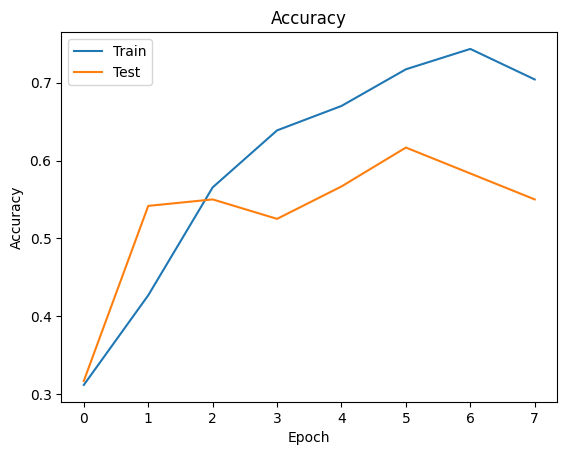

In [16]:
# Step 15: Accuracy Graph

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Test"])
plt.show()

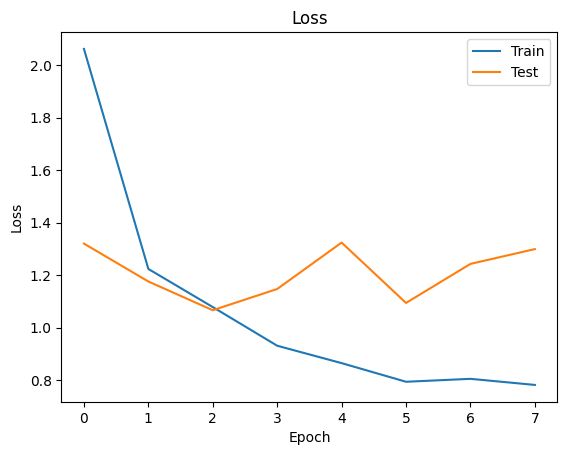

In [17]:
# Step 16: Loss Graph

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])
plt.show()

In [20]:
# Step 1: Upload Image

from google.colab import files
uploaded = files.upload()


Saving Screenshot 2026-04-25 065242.png to /content/drive/MyDrive/test.pnj/Screenshot 2026-04-25 065242.png


In [21]:
# Step 2: Load and Preprocess Image

from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

# Normalize (same as training)
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)


In [22]:
# Step 3: Prediction

predictions = model.predict(img_array)

predicted_class = np.argmax(predictions)
confidence = np.max(predictions)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", confidence * 100, "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Predicted Class: Rot_Apple
Confidence: 68.706 %


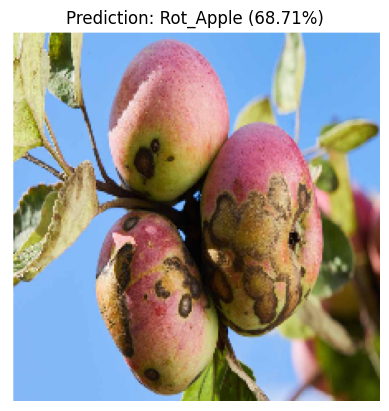

In [23]:
# Step 4: Display Result

import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {class_names[predicted_class]} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()


In [24]:
# Step 1: Upload Image

from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-04-25 065300.png to Screenshot 2026-04-25 065300.png


In [25]:
# Step 2: Load and Preprocess Image

from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

# Normalize (same as training)
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)


In [26]:
# Step 3: Prediction

predictions = model.predict(img_array)

predicted_class = np.argmax(predictions)
confidence = np.max(predictions)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", confidence * 100, "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Class: Scab_Apple
Confidence: 47.174038 %


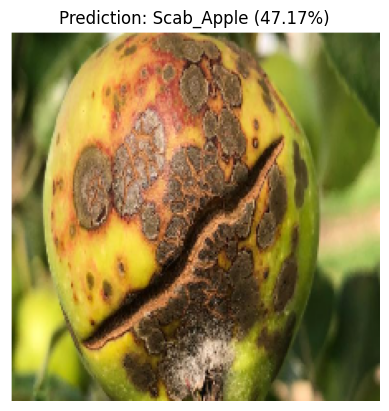

In [27]:
# Step 4: Display Result

import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {class_names[predicted_class]} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()


In [28]:
# Step 1: Upload Image

from google.colab import files
uploaded = files.upload()


Saving Screenshot 2026-04-25 071351.png to Screenshot 2026-04-25 071351.png


In [29]:
# Step 2: Load and Preprocess Image

from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

# Normalize (same as training)
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)


In [30]:
# Step 3: Prediction

predictions = model.predict(img_array)

predicted_class = np.argmax(predictions)
confidence = np.max(predictions)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", confidence * 100, "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted Class: Blotch_Apple
Confidence: 48.359837 %


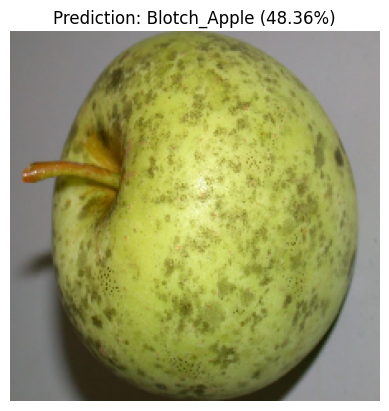

In [31]:
# Step 4: Display Result

import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {class_names[predicted_class]} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()


In [32]:
# Step 1: Upload Image

from google.colab import files
uploaded = files.upload()


Saving Screenshot 2026-04-25 071603.png to Screenshot 2026-04-25 071603.png


In [33]:
# Step 2: Load and Preprocess Image

from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

# Normalize (same as training)
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)


In [34]:
# Step 3: Prediction

predictions = model.predict(img_array)

predicted_class = np.argmax(predictions)
confidence = np.max(predictions)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", confidence * 100, "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Class: Normal_Apple
Confidence: 95.996124 %


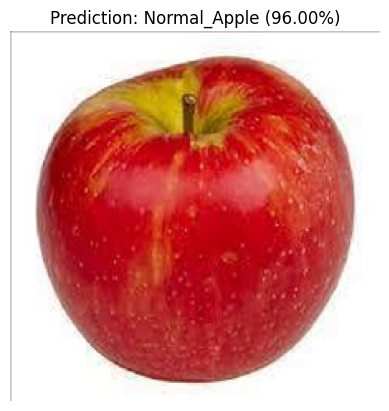

In [35]:
# Step 4: Display Result

import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {class_names[predicted_class]} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()


In [36]:
# Step 1: Upload Image

from google.colab import files
uploaded = files.upload()


Saving Screenshot 2026-04-25 071745.png to Screenshot 2026-04-25 071745.png


In [37]:
# Step 2: Load and Preprocess Image

from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

# Normalize (same as training)
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)


In [38]:
# Step 3: Prediction

predictions = model.predict(img_array)

predicted_class = np.argmax(predictions)
confidence = np.max(predictions)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", confidence * 100, "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Class: Scab_Apple
Confidence: 35.522507 %


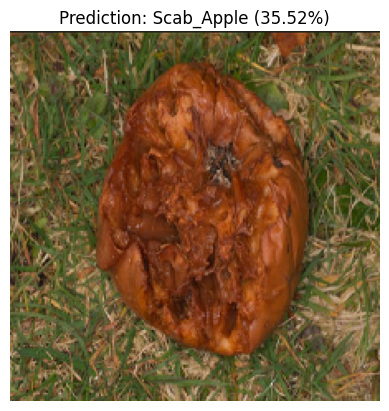

In [39]:
# Step 4: Display Result

import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {class_names[predicted_class]} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()
